In [24]:
import wandb
wandb.login()
runs = {"patch_icl": {"wandb_name": "tddpjz88"},
        "universeg" : {"wandb_name": "12cghpne"}
}
api = wandb.Api()
#metrics = api.run(f"/tidiane/patch_icl_eval/{run_names['patch_icl']}").history().transpose()
#wandb_metrics = run.history()
#print(wandb_metrics.columns)
#print(len(wandb_metrics))
#print(run.config)
# keep rows starting with dice_label/ and remove the prefix
#metrics = metrics[metrics.index.str.startswith("dice_label/")]
#metrics.index = metrics.index.str.replace("dice_label/", "")
#keep only first column
#metrics = metrics.iloc[:, 0]

In [25]:
# extract the table artifacts
for run_name in runs.keys():
    artifact = api.artifact(f"tidiane/patch_icl_eval/run-{runs[run_name]['wandb_name']}-per_case_dice:v0")
    artifact.download()

    table = artifact.get("per_case_dice.table.json")  # Replace with your table name
    df = table.get_dataframe()
    runs[run_name]["df"] = df

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


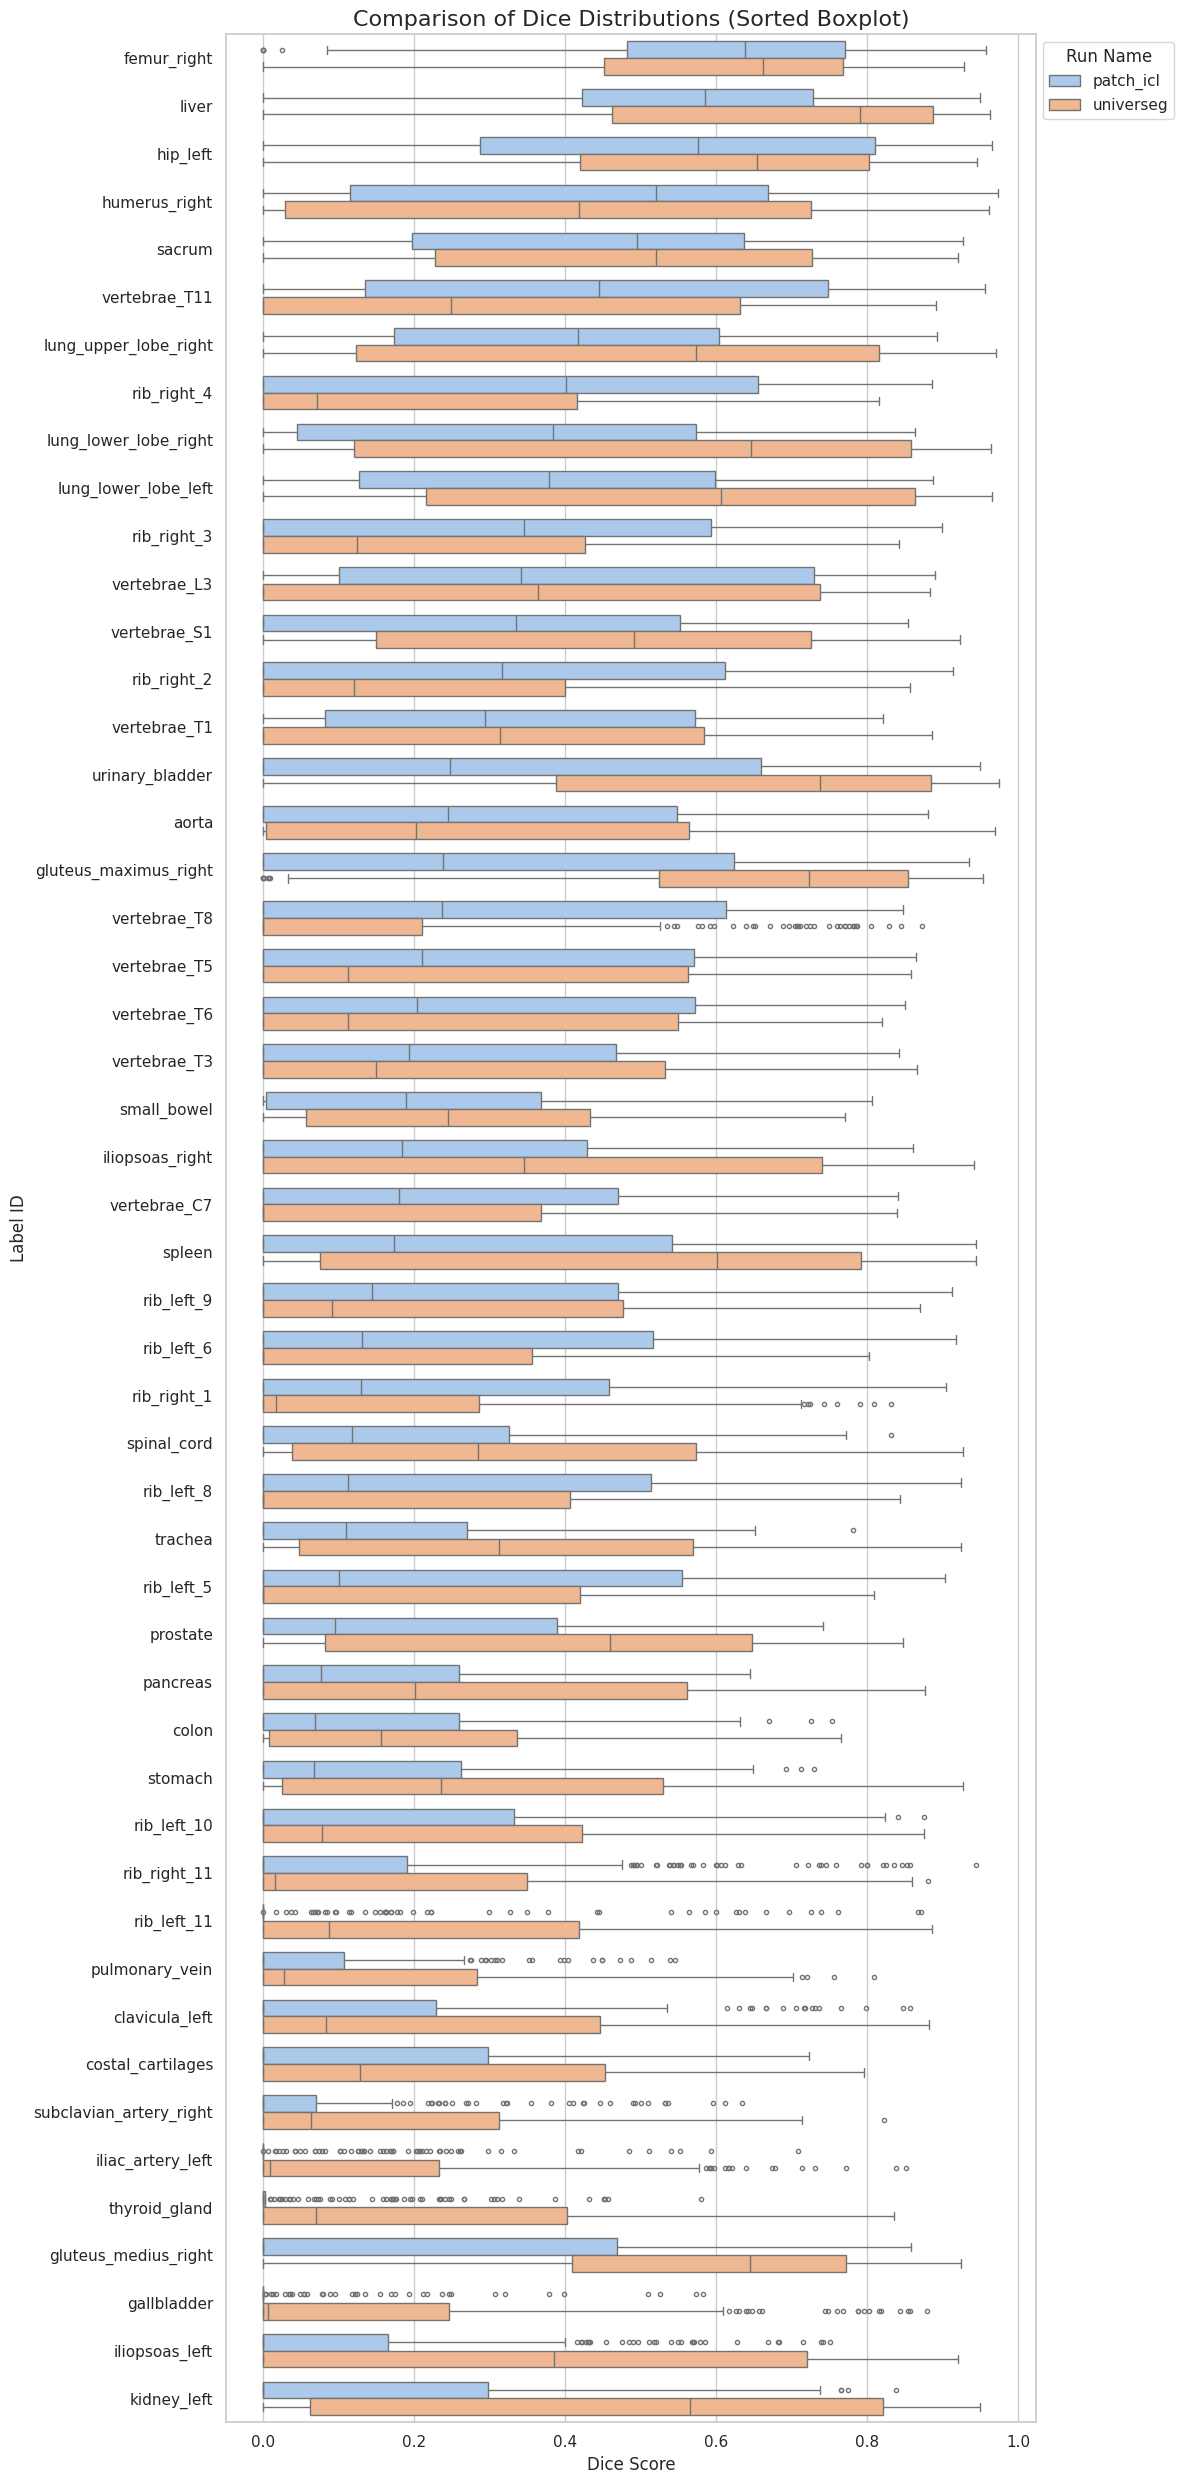

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. MERGE: Combine the two runs into a single DataFrame
combined_data = []

for run_name, run_data in runs.items():
    df_temp = run_data["df"].copy()
    # Add a column to identify the method (Run Name)
    df_temp["Run"] = run_name  
    combined_data.append(df_temp)

df_all = pd.concat(combined_data, ignore_index=True)

# 2. SORT: Calculate median Dice for the first run to sort labels
# This prevents the "random mess" look by creating a waterfall effect.
first_run_name = list(runs.keys())[0]

# Get the sort order (highest median to lowest)
sort_order = df_all[df_all['Run'] == first_run_name] \
             .groupby('label_id')['dice'].median() \
             .sort_values(ascending=False).index

# Apply the sort order to the 'label_id' column
df_all['label_id'] = pd.Categorical(
    df_all['label_id'], 
    categories=sort_order, 
    ordered=True
)

# 3. PLOT: Vertical Boxplot
# Tall height (25) is critical for 50 labels to be readable
plt.figure(figsize=(12, 25)) 
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_all,
    x="dice",           # Metric on X axis
    y="label_id",       # Labels on Y axis
    hue="Run",          # Compare the two runs side-by-side
    orient="h",         # Horizontal orientation
    palette="pastel",   # Softer colors
    width=0.7,          # Adjust box width to fit tightly
    linewidth=1.0,      # Thinner lines for clarity
    fliersize=3         # Smaller outlier dots
)

plt.title('Comparison of Dice Distributions (Sorted Boxplot)', fontsize=16)
plt.xlabel('Dice Score')
plt.ylabel('Label ID')

# Move legend outside if it covers data
plt.legend(title='Run Name', loc='upper left', bbox_to_anchor=(1, 1)) 

plt.tight_layout()
plt.show()

In [32]:
df_all.label_id.unique().tolist()

['colon',
 'femur_right',
 'gluteus_maximus_right',
 'gluteus_medius_right',
 'hip_left',
 'iliac_artery_left',
 'iliopsoas_left',
 'iliopsoas_right',
 'sacrum',
 'small_bowel',
 'urinary_bladder',
 'aorta',
 'costal_cartilages',
 'kidney_left',
 'liver',
 'lung_lower_lobe_left',
 'lung_lower_lobe_right',
 'pancreas',
 'prostate',
 'rib_left_10',
 'rib_left_11',
 'rib_left_5',
 'rib_left_6',
 'rib_left_8',
 'rib_left_9',
 'rib_right_11',
 'spinal_cord',
 'spleen',
 'stomach',
 'vertebrae_L3',
 'vertebrae_S1',
 'vertebrae_T11',
 'vertebrae_T8',
 'clavicula_left',
 'humerus_right',
 'lung_upper_lobe_right',
 'pulmonary_vein',
 'rib_right_1',
 'rib_right_2',
 'rib_right_3',
 'rib_right_4',
 'subclavian_artery_right',
 'thyroid_gland',
 'trachea',
 'vertebrae_C7',
 'vertebrae_T1',
 'vertebrae_T3',
 'vertebrae_T5',
 'vertebrae_T6',
 'gallbladder']

In [34]:
import pandas as pd

# 1. Define the Category Mapping
# This maps your specific 50 labels into 7 logical anatomical groups
category_map = {
    # --- ORGANS (ABDOMINAL & PELVIC) ---
    'colon': 'Organs (Abd/Pelvis)', 'small_bowel': 'Organs (Abd/Pelvis)',
    'stomach': 'Organs (Abd/Pelvis)', 'liver': 'Organs (Abd/Pelvis)', 
    'gallbladder': 'Organs (Abd/Pelvis)', 'pancreas': 'Organs (Abd/Pelvis)', 
    'spleen': 'Organs (Abd/Pelvis)', 'kidney_left': 'Organs (Abd/Pelvis)',
    'urinary_bladder': 'Organs (Abd/Pelvis)', 'prostate': 'Organs (Abd/Pelvis)',

    # --- ORGANS (THORACIC & NECK) ---
    'lung_lower_lobe_left': 'Organs (Thorax)', 'lung_lower_lobe_right': 'Organs (Thorax)',
    'lung_upper_lobe_right': 'Organs (Thorax)', 'trachea': 'Organs (Thorax)',
    'thyroid_gland': 'Organs (Thorax)', 'spinal_cord': 'Organs (Thorax)',

    # --- BONES (SPINE) ---
    'sacrum': 'Bones (Spine)', 'vertebrae_L3': 'Bones (Spine)', 'vertebrae_S1': 'Bones (Spine)',
    'vertebrae_T8': 'Bones (Spine)', 'vertebrae_T11': 'Bones (Spine)',
    'vertebrae_C7': 'Bones (Spine)', 'vertebrae_T1': 'Bones (Spine)', 
    'vertebrae_T3': 'Bones (Spine)', 'vertebrae_T5': 'Bones (Spine)', 
    'vertebrae_T6': 'Bones (Spine)',

    # --- BONES (RIBS) ---
    'costal_cartilages': 'Bones (Ribs)',
    'rib_left_5': 'Bones (Ribs)', 'rib_left_6': 'Bones (Ribs)', 
    'rib_left_8': 'Bones (Ribs)', 'rib_left_9': 'Bones (Ribs)', 
    'rib_left_10': 'Bones (Ribs)', 'rib_left_11': 'Bones (Ribs)',
    'rib_right_1': 'Bones (Ribs)', 'rib_right_2': 'Bones (Ribs)', 
    'rib_right_3': 'Bones (Ribs)', 'rib_right_4': 'Bones (Ribs)', 
    'rib_right_11': 'Bones (Ribs)',

    # --- BONES (OTHER) ---
    'femur_right': 'Bones (Other)', 'hip_left': 'Bones (Other)',
    'clavicula_left': 'Bones (Other)', 'humerus_right': 'Bones (Other)',

    # --- MUSCLES ---
    'gluteus_maximus_right': 'Muscles', 'gluteus_medius_right': 'Muscles',
    'iliopsoas_left': 'Muscles', 'iliopsoas_right': 'Muscles',

    # --- VESSELS ---
    'aorta': 'Vessels', 'iliac_artery_left': 'Vessels',
    'pulmonary_vein': 'Vessels', 'subclavian_artery_right': 'Vessels'
}

# 2. Apply Mapping to DataFrame
# Assuming 'df_all' is your combined dataframe from the previous step
df_all['Category'] = df_all['label_id'].map(category_map)

# Fill any missing keys (safety check) with 'Uncategorized'
df_all['Category'] = df_all['Category'].fillna('Uncategorized')

# 3. Calculate Averages
# Group by Category and Run, then calculate the mean Dice score
stats = df_all.groupby(['Category', 'Run'])['dice'].mean().unstack()

# 4. Print Formatting
print("="*60)
print(f"{'Average Dice Score by Category':^60}")
print("="*60)
# Round to 4 decimal places for cleaner output
print(stats.round(4))
print("-" * 60)

# Optional: Calculate Global Average per Method
global_avg = df_all.groupby('Run')['dice'].mean()
print(f"\nGlobal Average:\n{global_avg.round(4)}")
print("="*60)

               Average Dice Score by Category               
Run                  patch_icl  universeg
Category                                 
Bones (Other)           0.4255     0.4542
Bones (Ribs)            0.2293     0.2052
Bones (Spine)           0.3342     0.3045
Muscles                 0.2131     0.4720
Organs (Abd/Pelvis)     0.2235     0.3809
Organs (Thorax)         0.2652     0.4159
Vessels                 0.1433     0.2086
------------------------------------------------------------

Global Average:
Run
patch_icl    0.2566
universeg    0.3256
Name: dice, dtype: float64


In [ ]:
from pathlib import Path
totalseg_dir = Path("/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/data/TotalSeg")
df_label_stats = pd.read_csv(totalseg_dir / "label_stats.csv", index_col="label_id")
print(df_label_stats.columns)

                   occurrences     avg_volume
label_id                                     
spinal_cord               1183   15882.996619
autochthon_left           1133   84760.713151
autochthon_right          1131   84166.481874
aorta                     1104   55447.712862
esophagus                 1033    8074.079380
...                        ...            ...
vertebrae_C4               250    3465.568000
brain                      249  204927.823293
vertebrae_C3               229    3623.135371
kidney_cyst_left            30   23475.466667
kidney_cyst_right           25   28289.760000

[117 rows x 2 columns]


/tmp/ipykernel_2646856/140234543.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_dice_avg = df_all.groupby(['label_id', 'Run'], as_index=False)['dice'].mean()


patch_icl - Volume Correlation (Spearman): 0.35
universeg - Volume Correlation (Spearman): 0.75
patch_icl - Occurrence Correlation (Spearman): -0.10
universeg - Occurrence Correlation (Spearman): -0.13


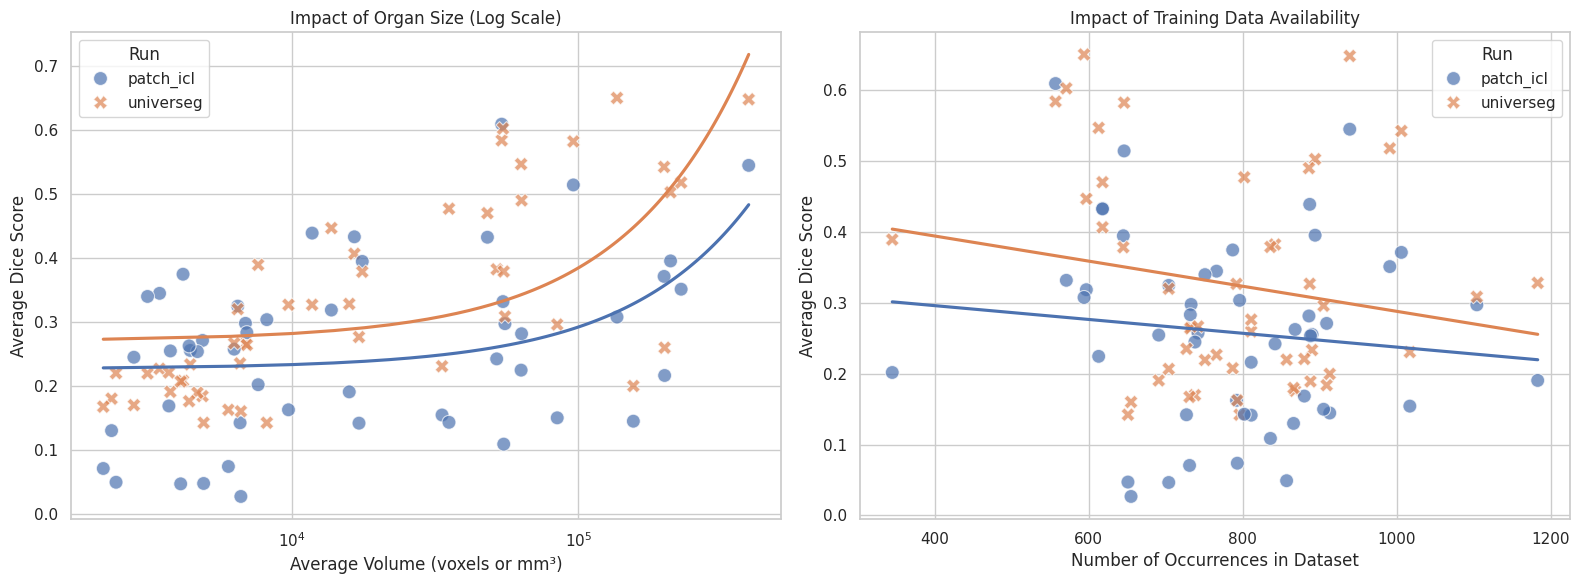

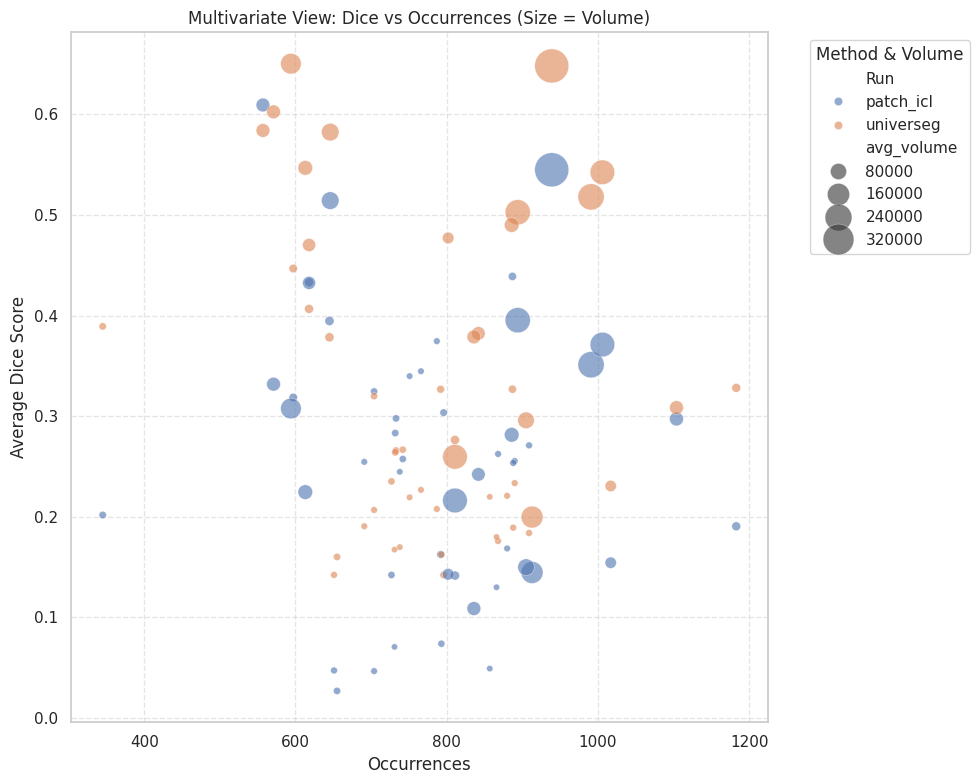

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# 1. PREPARE DATA
# ---------------------------------------------------------
# Step A: Calculate average Dice per label for each method
# (Assuming 'df_all' is the combined dataframe from previous steps)
df_dice_avg = df_all.groupby(['label_id', 'Run'], as_index=False)['dice'].mean()

# Step B: Merge with your meta-data (volume & occurrences)
# specific_stats_df should have columns: ['label_id', 'avg_volume', 'occurences']
# If you don't have it loaded yet:
specific_stats_df = pd.read_csv(totalseg_dir / "label_stats.csv")

df_final = pd.merge(df_dice_avg, specific_stats_df, on='label_id')

# 2. PLOT: Dual Scatter Plot (Clearest Correlation View)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- Plot A: Volume vs Dice (Log Scale) ---
sns.scatterplot(
    data=df_final, 
    x="avg_volume", 
    y="dice", 
    hue="Run", 
    style="Run",
    s=100, alpha=0.7, 
    ax=axes[0]
)
# Add trend lines (optional, using regplot)
colors = sns.color_palette()
for i, method in enumerate(df_final['Run'].unique()):
    subset = df_final[df_final['Run'] == method]
    sns.regplot(
        data=subset, x="avg_volume", y="dice", 
        scatter=False, ax=axes[0], color=colors[i], ci=None
    )
    # Calculate Correlation (Spearman for non-linear volume relationships)
    corr, _ = spearmanr(subset['avg_volume'], subset['dice'])
    print(f"{method} - Volume Correlation (Spearman): {corr:.2f}")

axes[0].set_xscale("log") # Crucial for volume!
axes[0].set_title("Impact of Organ Size (Log Scale)")
axes[0].set_xlabel("Average Volume (voxels or mm³)")
axes[0].set_ylabel("Average Dice Score")

# --- Plot B: Occurrences vs Dice ---
sns.scatterplot(
    data=df_final, 
    x="occurrences", 
    y="dice", 
    hue="Run", 
    style="Run",
    s=100, alpha=0.7, 
    ax=axes[1]
)
# Add trend lines
for i, method in enumerate(df_final['Run'].unique()):
    subset = df_final[df_final['Run'] == method]
    sns.regplot(
        data=subset, x="occurrences", y="dice", 
        scatter=False, ax=axes[1], color=colors[i], ci=None
    )
    # Pearson is usually fine for counts
    corr, _ = spearmanr(subset['occurrences'], subset['dice'])
    print(f"{method} - Occurrence Correlation (Spearman): {corr:.2f}")

axes[1].set_title("Impact of Training Data Availability")
axes[1].set_xlabel("Number of Occurrences in Dataset")
axes[1].set_ylabel("Average Dice Score")

plt.tight_layout()
plt.show()

# 3. ALTERNATIVE: Multivariate Bubble Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_final,
    x="occurrences",
    y="dice",
    size="avg_volume",  # Bubble size = Volume
    sizes=(20, 600),    # Range of bubble sizes
    hue="Run",
    alpha=0.6,
    palette="deep"
)
plt.title("Multivariate View: Dice vs Occurrences (Size = Volume)")
plt.xlabel("Occurrences")
plt.ylabel("Average Dice Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Method & Volume")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()